[*********************100%***********************]  1 of 1 completed

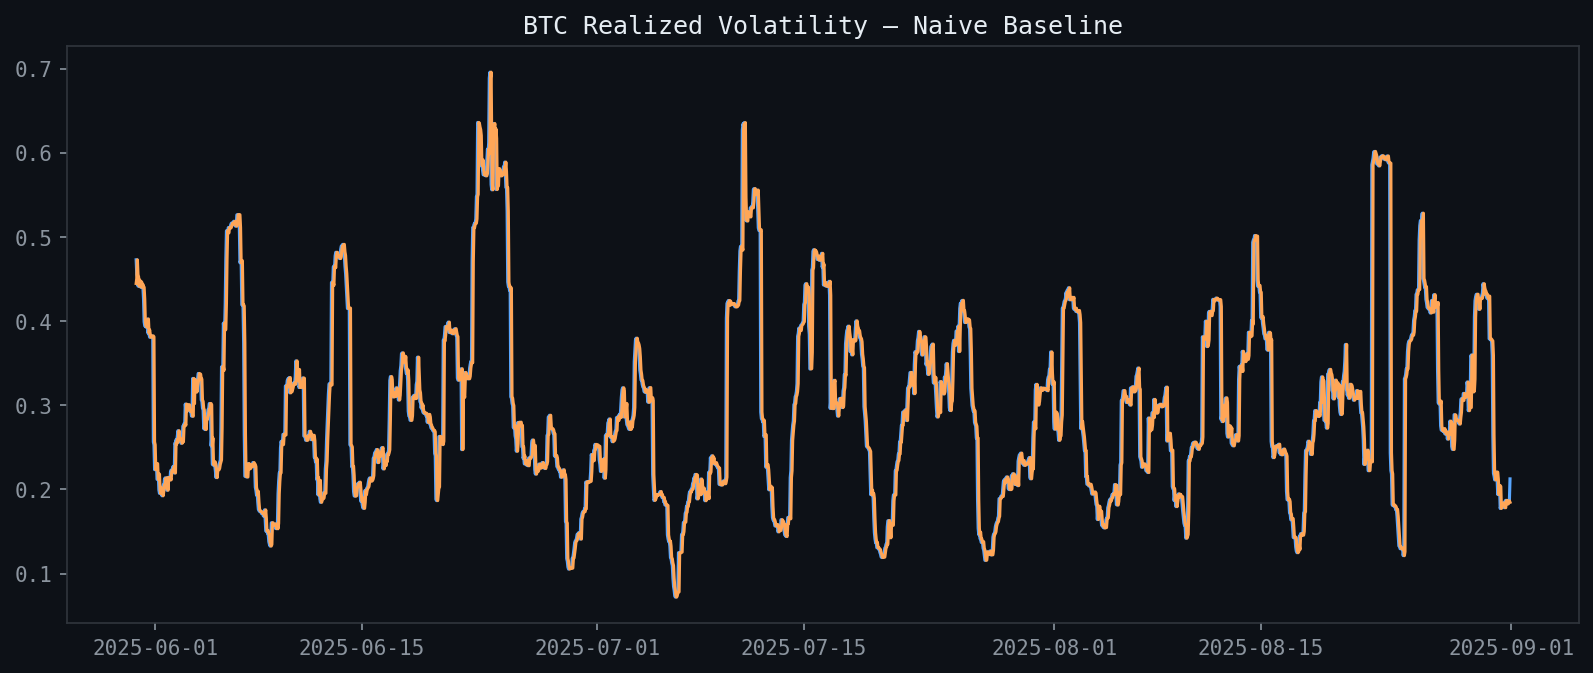

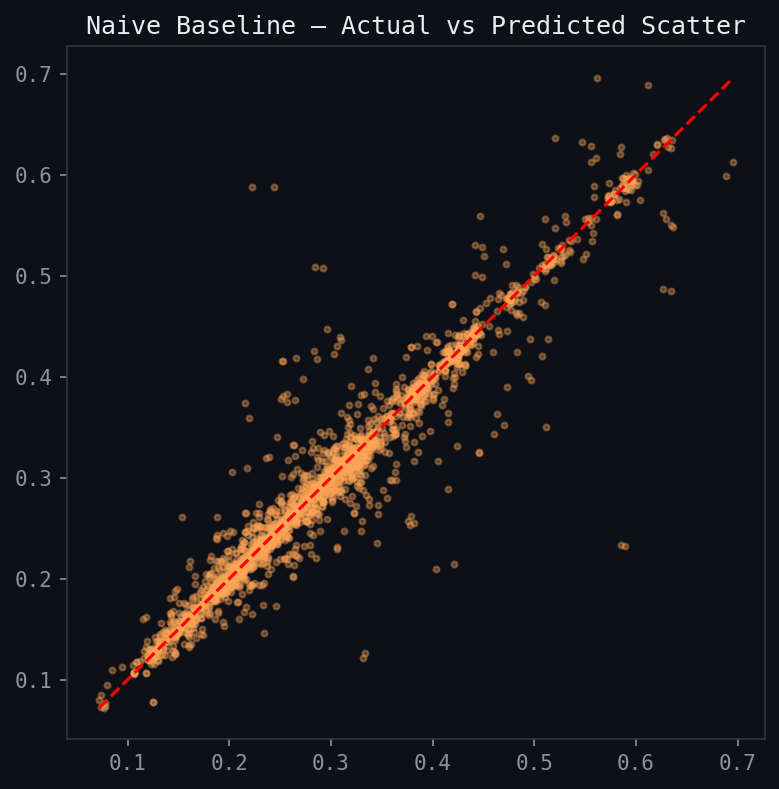

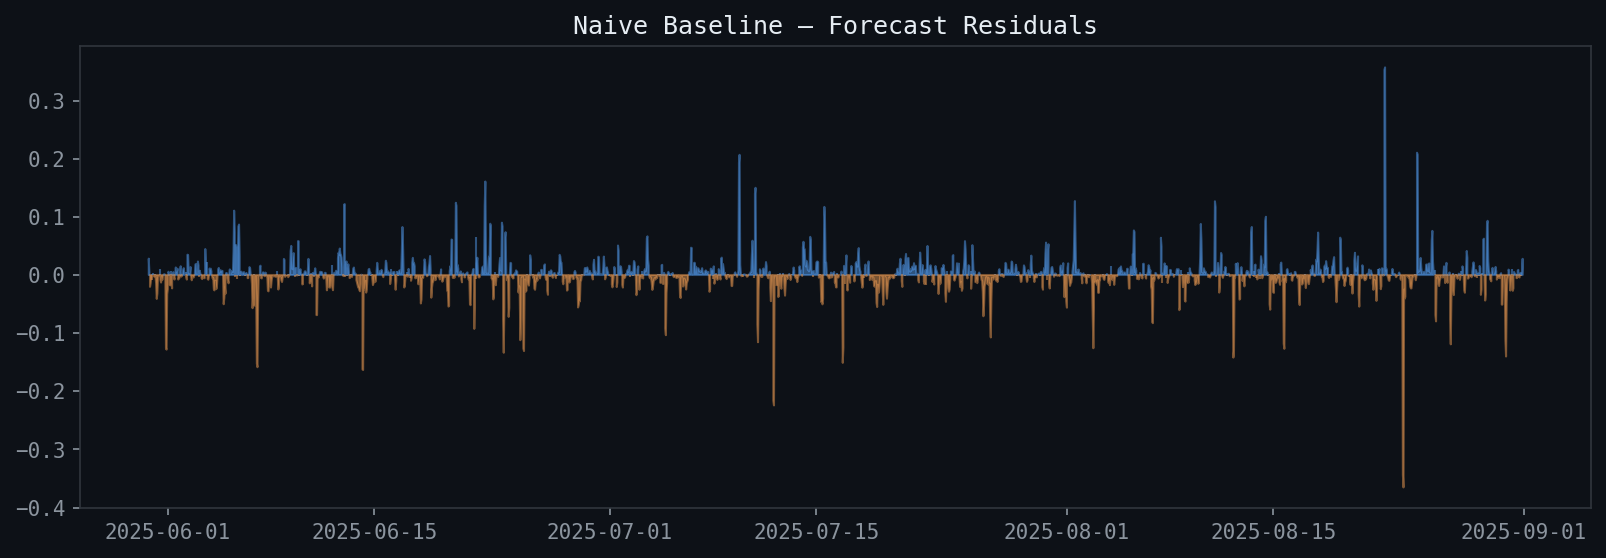

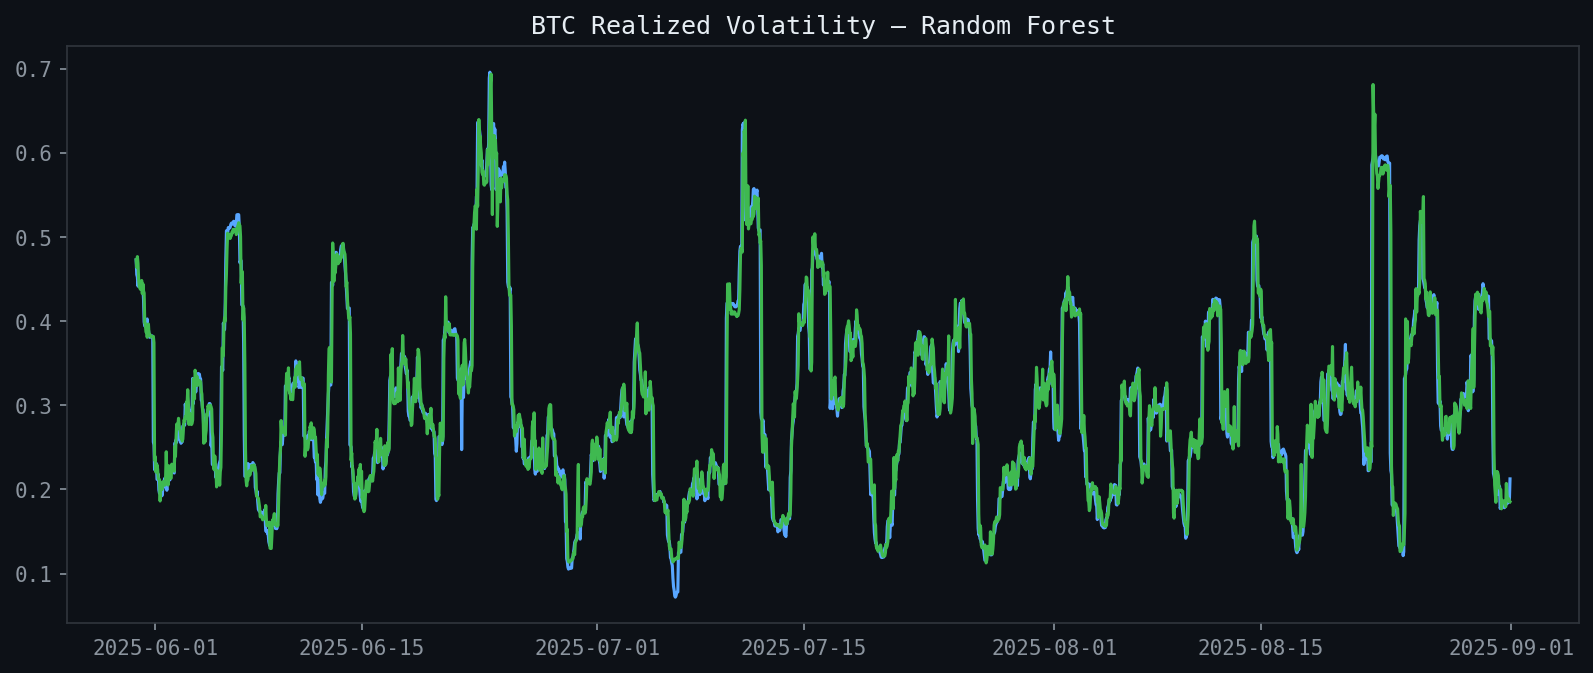

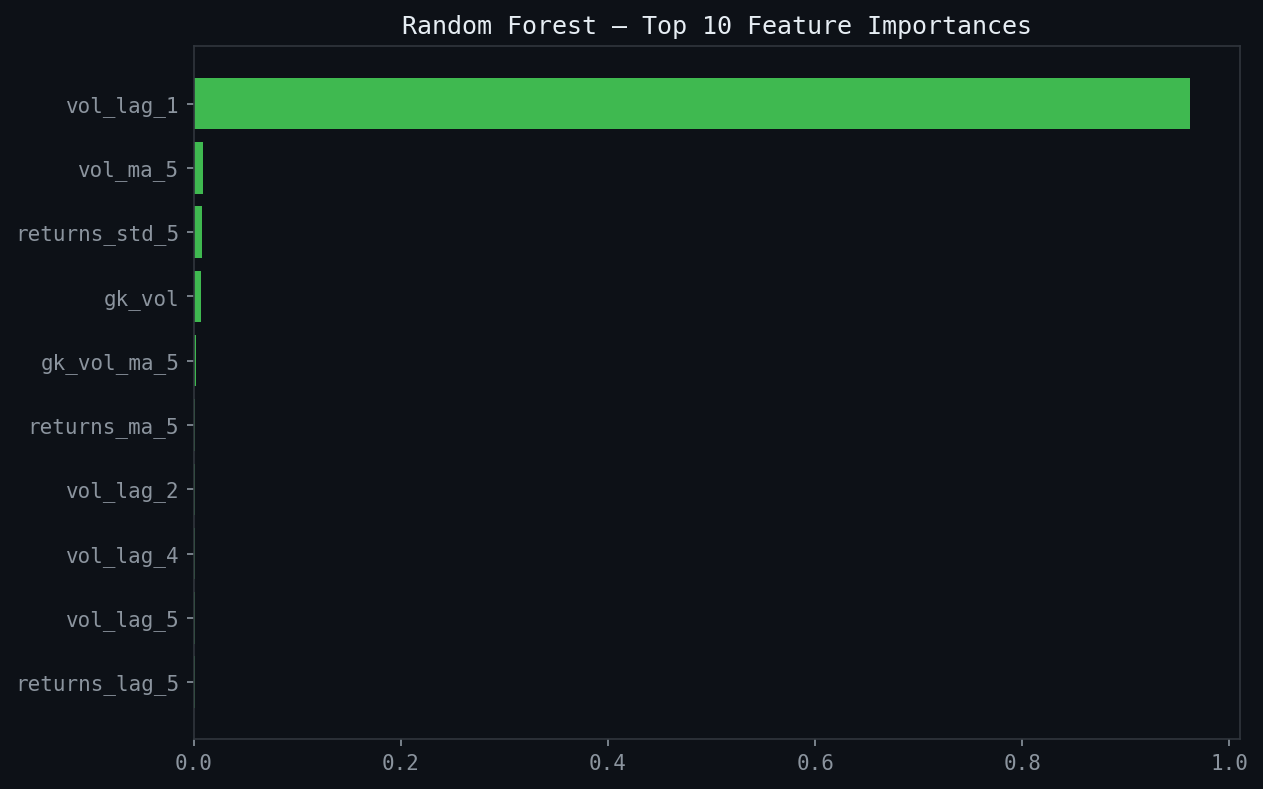

/opt/anaconda3/envs/my_env_311/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


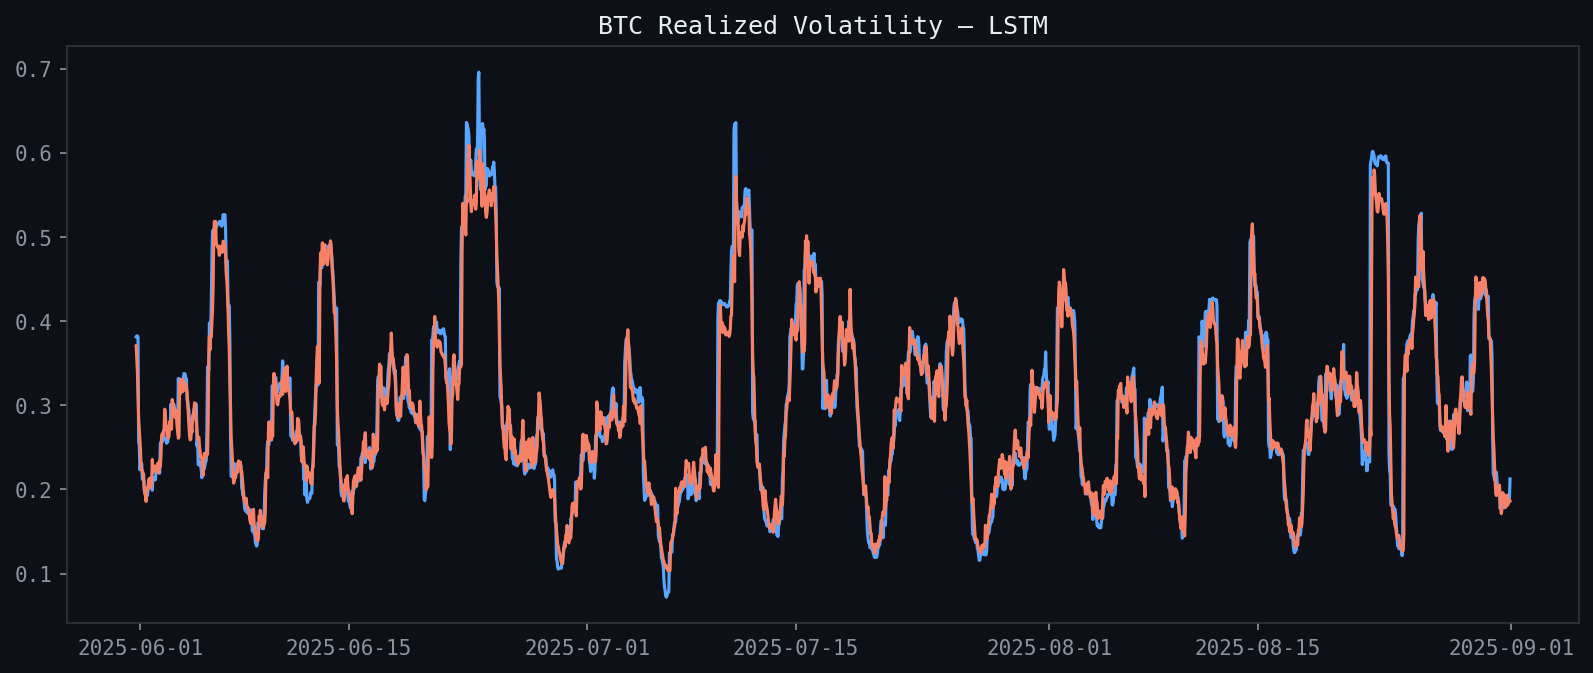

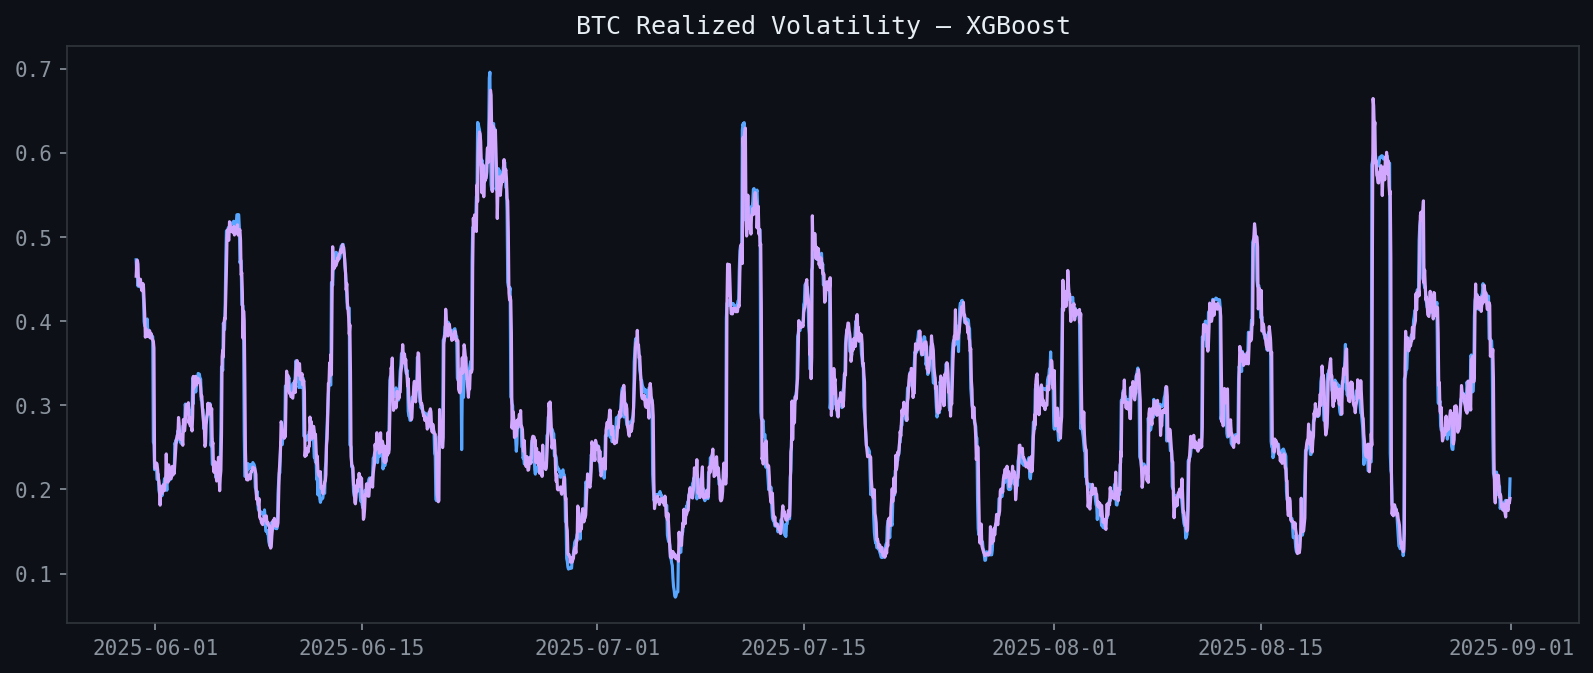

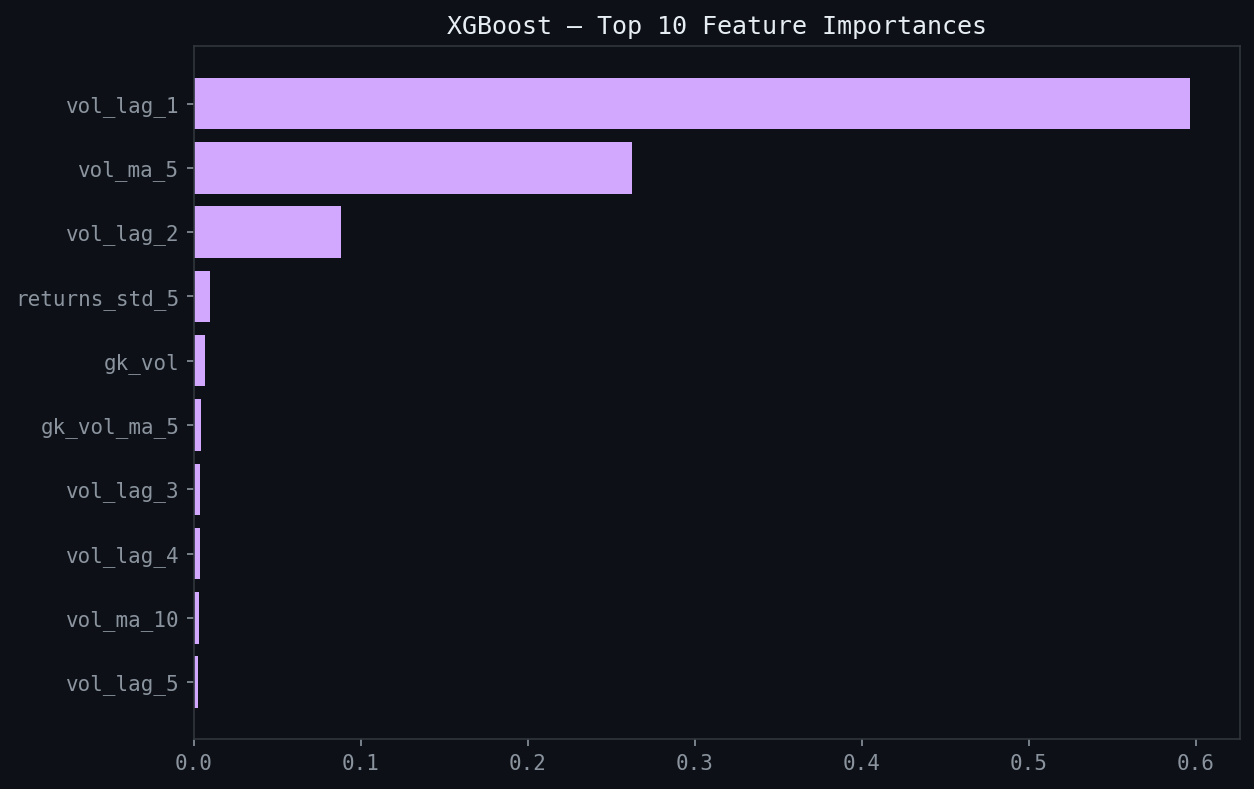

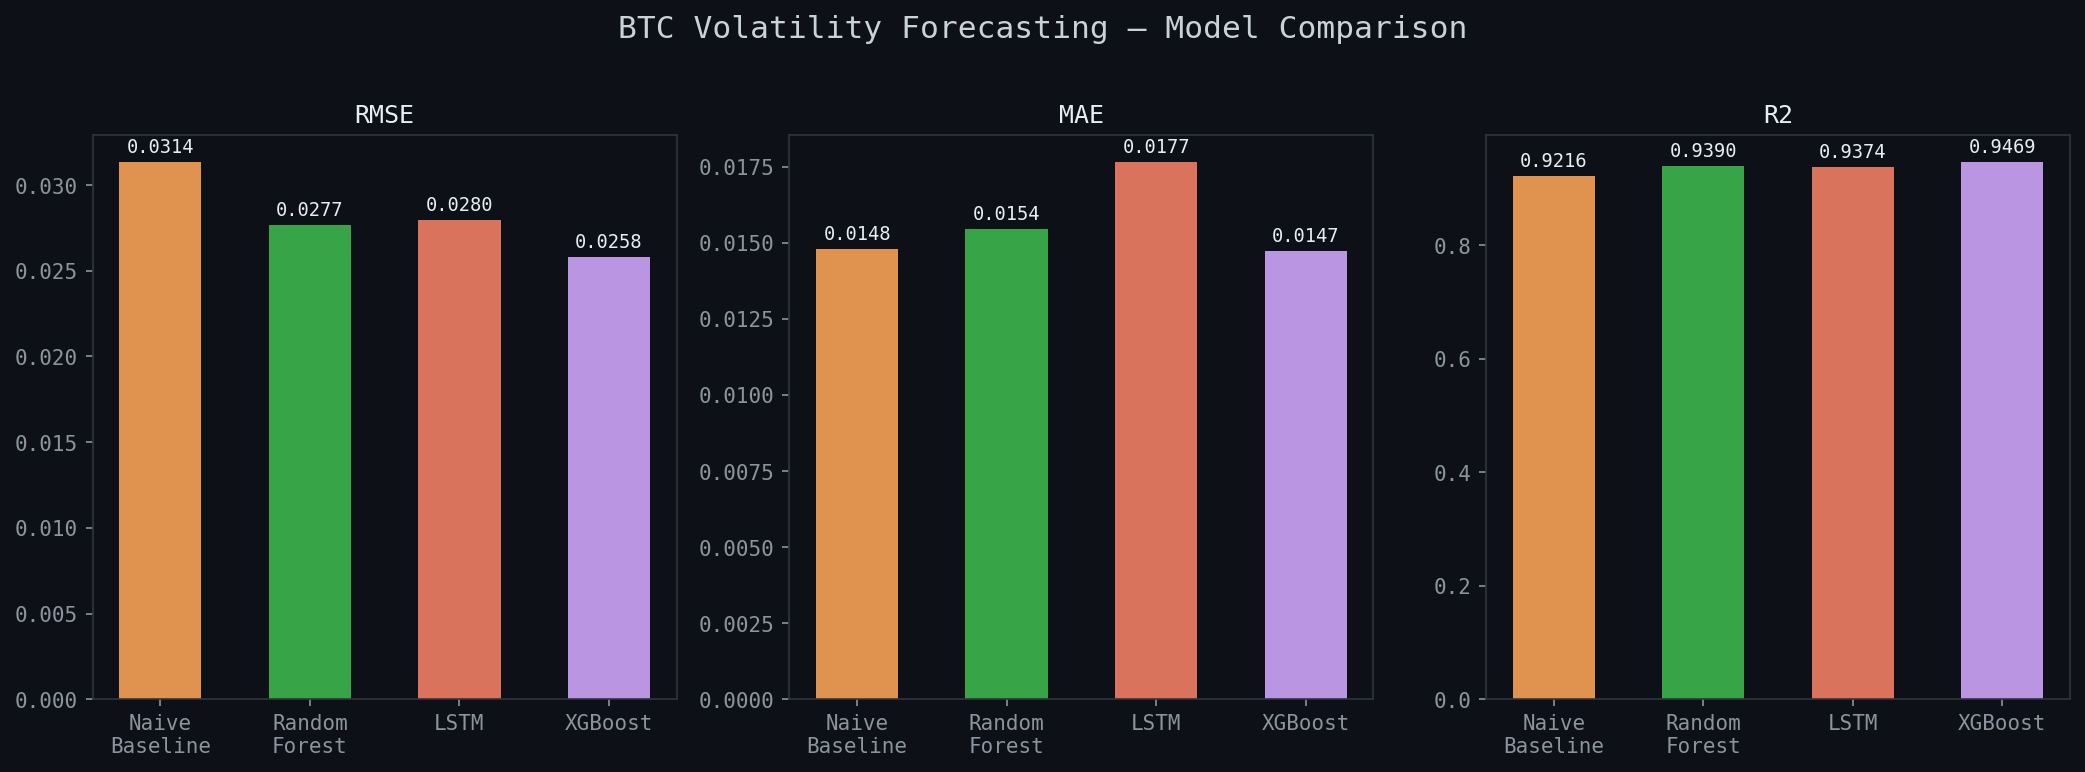

[*********************100%***********************]  1 of 1 completed


Processing ETH-USD comparison...



/opt/anaconda3/envs/my_env_311/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


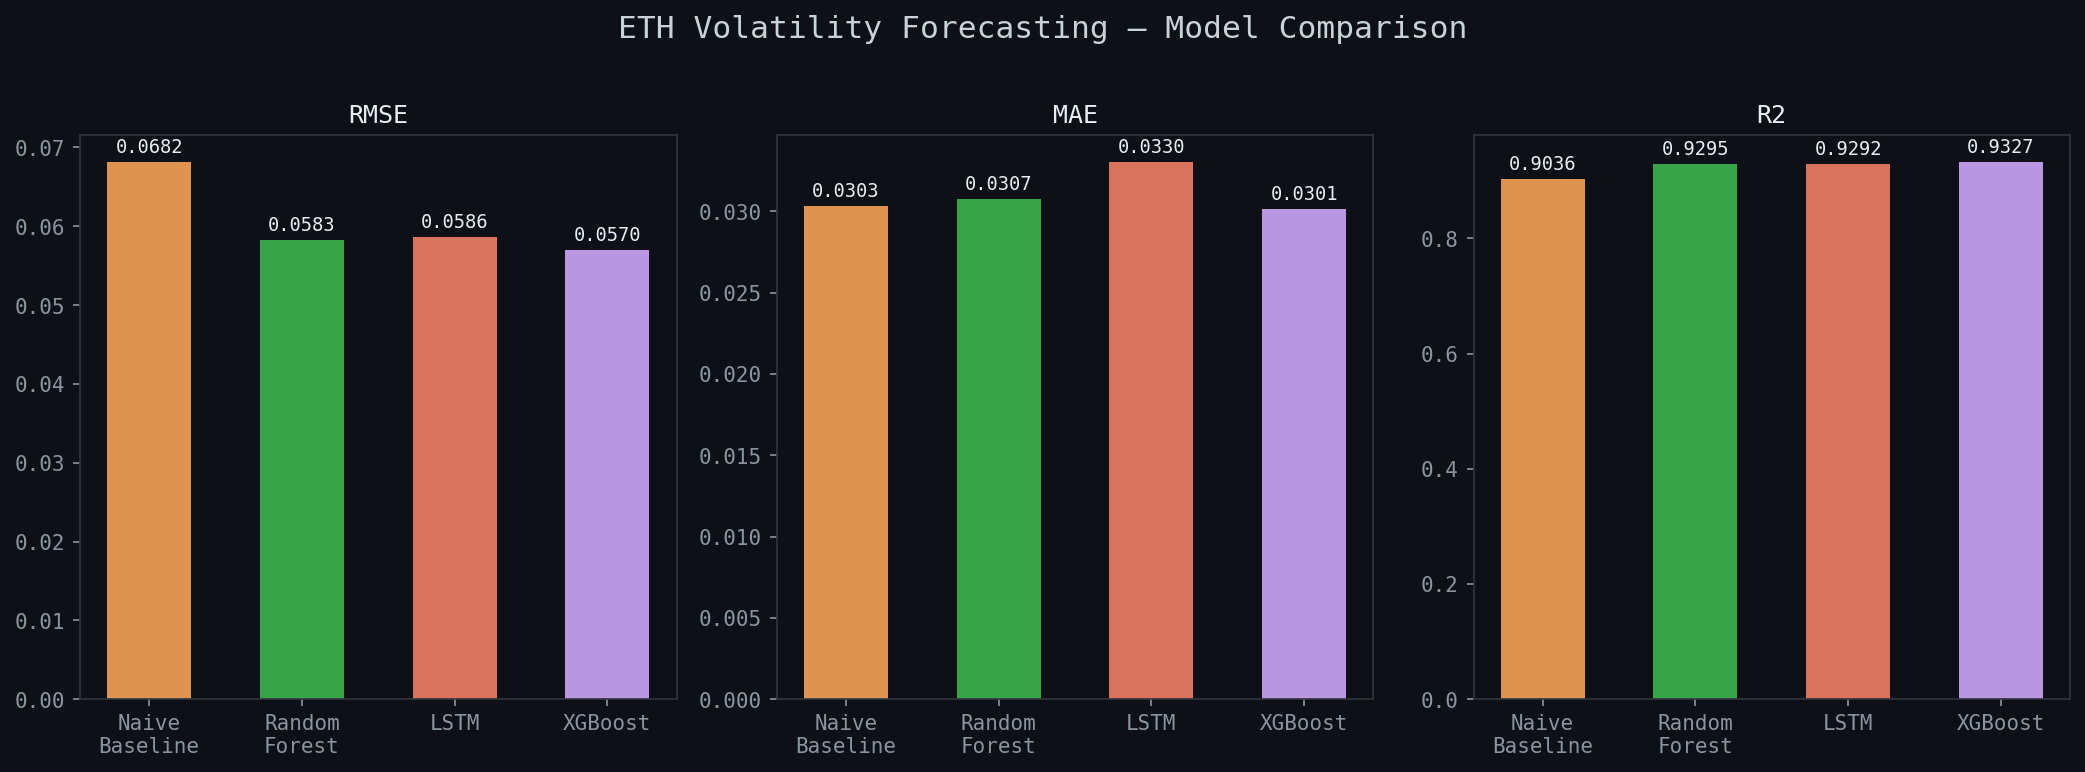

In [5]:
"""
Cryptocurrency Volatility Forecasting
Models: Naive Baseline, Random Forest, LSTM, XGBoost
Data:   BTC-USD & ETH-USD hourly, Jul 2024 – Sep 2025
"""

# =============================================================================
# 0. REPRODUCIBILITY & IMPORTS
# =============================================================================
import os, gc, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import xgboost as xgb

# ── Presentation-grade plot style ────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#0d1117",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "axes.titlecolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "text.color":       "#c9d1d9",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
    "figure.dpi":       150,
})
COLORS = {
    "actual":  "#58a6ff",
    "rf":      "#3fb950",
    "lstm":    "#f78166",
    "xgb":     "#d2a8ff",
    "naive":   "#ffa657",
    "accent":  "#e6edf3",
}

# =============================================================================
# 1. UTILITIES
# =============================================================================
ANNUALISE = np.sqrt(24 * 365)
WINDOW    = 30

def garman_klass_vol(df: pd.DataFrame) -> pd.Series:
    log_hl = np.log(df["High"] / df["Low"])
    log_co = np.log(df["Close"] / df["Open"])
    gk_var = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
    gk_var = gk_var.clip(lower=0)
    return np.sqrt(gk_var) * ANNUALISE

def add_vol_columns(df: pd.DataFrame, window: int = WINDOW) -> pd.DataFrame:
    df = df.copy()
    df["log_returns"]     = np.log(df["Close"] / df["Close"].shift(1))
    df["squared_returns"] = df["log_returns"] ** 2
    df["realized_vol"]    = df["log_returns"].rolling(window).std() * ANNUALISE
    df["gk_vol"]          = garman_klass_vol(df)
    return df.dropna()

def create_volatility_features(data: pd.DataFrame, lags: int = 5) -> pd.DataFrame:
    f = pd.DataFrame(index=data.index)
    for i in range(1, lags + 1):
        f[f"returns_lag_{i}"]    = data["log_returns"].shift(i)
        f[f"sq_returns_lag_{i}"] = data["squared_returns"].shift(i)
        f[f"vol_lag_{i}"]        = data["realized_vol"].shift(i)
    f["vol_ma_5"]      = data["realized_vol"].rolling(5).mean()
    f["vol_ma_10"]     = data["realized_vol"].rolling(10).mean()
    f["returns_ma_5"]  = data["log_returns"].rolling(5).mean()
    f["returns_std_5"] = data["log_returns"].rolling(5).std()
    f["gk_vol"]        = data["gk_vol"]
    f["gk_vol_ma_5"]   = data["gk_vol"].rolling(5).mean()
    return f

def make_xy(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    feat     = create_volatility_features(data)
    target   = data["realized_vol"].shift(-1)
    combined = pd.concat([feat, target.rename("target")], axis=1).dropna()
    X = combined.drop(columns="target")
    y = combined["target"]
    return X, y

def create_sequences(X: np.ndarray, y: np.ndarray, window: int = 24):
    n = len(X) - window
    X_seq = np.stack([X[i : i + window] for i in range(n)])
    y_seq = y[window:]
    return X_seq, y_seq

# =============================================================================
# 2. BTC-USD FULL WORKFLOW (RESTORED TO ORIGINAL)
# =============================================================================
print("Downloading BTC-USD hourly data …")
btc = yf.download("BTC-USD", start="2024-07-01", end="2025-09-01", interval="1h", auto_adjust=True)
btc.columns = btc.columns.get_level_values(0)

train_ratio = 14 / 18
split_idx   = int(len(btc) * train_ratio)
btc_train = add_vol_columns(btc.iloc[:split_idx])
btc_test  = add_vol_columns(btc.iloc[split_idx:])

X_train, y_train = make_xy(btc_train)
X_test,  y_test  = make_xy(btc_test)

# --- NAIVE ---
naive_preds = X_test["vol_lag_1"]
rmse_naive, mae_naive, r2_naive = np.sqrt(mean_squared_error(y_test, naive_preds)), mean_absolute_error(y_test, naive_preds), r2_score(y_test, naive_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index, y_test.values, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index, naive_preds.values, color=COLORS["naive"], label="Naive")
ax.set_title("BTC Realized Volatility — Naive Baseline"); plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test.values, naive_preds.values, alpha=0.35, s=8, color=COLORS["naive"])
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax.set_title("Naive Baseline — Actual vs Predicted Scatter"); plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
res = y_test.values - naive_preds.values
ax.fill_between(y_test.index, res, 0, where=(res >= 0), color=COLORS["actual"], alpha=0.45)
ax.fill_between(y_test.index, res, 0, where=(res < 0),  color=COLORS["naive"],  alpha=0.45)
ax.set_title("Naive Baseline — Forecast Residuals"); plt.show()

# --- RANDOM FOREST ---
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rmse_rf, mae_rf, r2_rf = np.sqrt(mean_squared_error(y_test, rf_preds)), mean_absolute_error(y_test, rf_preds), r2_score(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index, y_test.values, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index, rf_preds, color=COLORS["rf"], label="Random Forest")
ax.set_title("BTC Realized Volatility — Random Forest"); plt.show()

rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(rf_imp.index, rf_imp.values, color=COLORS["rf"]); ax.set_title("Random Forest — Top 10 Feature Importances"); plt.show()

# --- LSTM ---
scaler_x, scaler_y = MinMaxScaler(), MinMaxScaler()
X_tr_sc, X_te_sc = scaler_x.fit_transform(X_train), scaler_x.transform(X_test)
y_tr_sc, y_te_sc = scaler_y.fit_transform(y_train.values.reshape(-1, 1)), scaler_y.transform(y_test.values.reshape(-1, 1))
X_s, y_s = create_sequences(X_tr_sc, y_tr_sc, 24); X_ts, y_ts = create_sequences(X_te_sc, y_te_sc, 24)

lstm_model = Sequential([LSTM(50, activation="tanh", input_shape=(24, X_train.shape[1])), Dropout(0.2), Dense(25, activation="relu"), Dense(1)])
lstm_model.compile(optimizer="adam", loss="mse")
history = lstm_model.fit(X_s, y_s, epochs=20, batch_size=32, validation_split=0.1, verbose=0)
lstm_preds = scaler_y.inverse_transform(lstm_model.predict(X_ts, verbose=0)).flatten()
y_test_lstm = scaler_y.inverse_transform(y_ts).flatten()
rmse_lstm, mae_lstm, r2_lstm = np.sqrt(mean_squared_error(y_test_lstm, lstm_preds)), mean_absolute_error(y_test_lstm, lstm_preds), r2_score(y_test_lstm, lstm_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index[24:], y_test_lstm, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index[24:], lstm_preds, color=COLORS["lstm"], label="LSTM")
ax.set_title("BTC Realized Volatility — LSTM"); plt.show()

# --- XGBOOST (RESTORED PARAMETERS) ---
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror", tree_method="hist", early_stopping_rounds=50, random_state=SEED)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = xgb_model.predict(X_test)
rmse_xgb, mae_xgb, r2_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds)), mean_absolute_error(y_test, xgb_preds), r2_score(y_test, xgb_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index, y_test.values, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index, xgb_preds, color=COLORS["xgb"], label="XGBoost")
ax.set_title("BTC Realized Volatility — XGBoost"); plt.show()

xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(xgb_imp.index, xgb_imp.values, color=COLORS["xgb"]); ax.set_title("XGBoost — Top 10 Feature Importances"); plt.show()

# BTC Summary Plot
results_btc = {"Naive\nBaseline": {"rmse": rmse_naive, "mae": mae_naive, "r2": r2_naive}, "Random\nForest": {"rmse": rmse_rf, "mae": mae_rf, "r2": r2_rf}, "LSTM": {"rmse": rmse_lstm, "mae": mae_lstm, "r2": r2_lstm}, "XGBoost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb}}
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("BTC Volatility Forecasting — Model Comparison", fontsize=15, y=1.02)
for i, metric in enumerate(["rmse", "mae", "r2"]):
    vals = [results_btc[m][metric] for m in results_btc]
    bars = axes[i].bar(results_btc.keys(), vals, color=[COLORS["naive"], COLORS["rf"], COLORS["lstm"], COLORS["xgb"]], alpha=0.88, width=0.55)
    axes[i].set_title(metric.upper())
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=9, color=COLORS["accent"])
plt.tight_layout(); plt.show()

# =============================================================================
# 3. ETH-USD SECTION (COMPARISON GRAPH ONLY)
# =============================================================================
print("\nProcessing ETH-USD comparison...")
eth = yf.download("ETH-USD", start="2024-07-01", end="2025-09-01", interval="1h", auto_adjust=True)
eth.columns = eth.columns.get_level_values(0)
eth_train = add_vol_columns(eth.iloc[:split_idx]); eth_test = add_vol_columns(eth.iloc[split_idx:])
EX_tr, Ey_tr = make_xy(eth_train); EX_te, Ey_te = make_xy(eth_test)

# Naive
en_p = EX_te["vol_lag_1"]
# RF
erf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED).fit(EX_tr, Ey_tr)
# LSTM
esx, esy = MinMaxScaler(), MinMaxScaler()
EX_tr_s, EX_te_s = esx.fit_transform(EX_tr), esx.transform(EX_te)
Ey_tr_s = esy.fit_transform(Ey_tr.values.reshape(-1,1))
EX_s, Ey_s = create_sequences(EX_tr_s, Ey_tr_s, 24); EX_ts, Ey_ts = create_sequences(EX_te_s, esy.transform(Ey_te.values.reshape(-1,1)), 24)
em = Sequential([LSTM(50, input_shape=(24, EX_tr.shape[1])), Dense(1)]); em.compile(optimizer="adam", loss="mse")
em.fit(EX_s, Ey_s, epochs=15, verbose=0)
em_p = esy.inverse_transform(em.predict(EX_ts, verbose=0)).flatten()
# XGB
exg = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, early_stopping_rounds=50, random_state=SEED)
exg.fit(EX_tr, Ey_tr, eval_set=[(EX_te, Ey_te)], verbose=False)

results_eth = {
    "Naive\nBaseline": {"rmse": np.sqrt(mean_squared_error(Ey_te, en_p)), "mae": mean_absolute_error(Ey_te, en_p), "r2": r2_score(Ey_te, en_p)},
    "Random\nForest":  {"rmse": np.sqrt(mean_squared_error(Ey_te, erf.predict(EX_te))), "mae": mean_absolute_error(Ey_te, erf.predict(EX_te)), "r2": r2_score(Ey_te, erf.predict(EX_te))},
    "LSTM":            {"rmse": np.sqrt(mean_squared_error(esy.inverse_transform(Ey_ts).flatten(), em_p)), "mae": mean_absolute_error(esy.inverse_transform(Ey_ts).flatten(), em_p), "r2": r2_score(esy.inverse_transform(Ey_ts).flatten(), em_p)},
    "XGBoost":         {"rmse": np.sqrt(mean_squared_error(Ey_te, exg.predict(EX_te))), "mae": mean_absolute_error(Ey_te, exg.predict(EX_te)), "r2": r2_score(Ey_te, exg.predict(EX_te))},
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("ETH Volatility Forecasting — Model Comparison", fontsize=15, y=1.02)
for i, metric in enumerate(["rmse", "mae", "r2"]):
    vals = [results_eth[m][metric] for m in results_eth]
    bars = axes[i].bar(results_eth.keys(), vals, color=[COLORS["naive"], COLORS["rf"], COLORS["lstm"], COLORS["xgb"]], alpha=0.88, width=0.55)
    axes[i].set_title(metric.upper())
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=9, color=COLORS["accent"])
plt.tight_layout(); plt.show()